In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from psana import DataSource
sys.path.append('/sdf/data/lcls/ds/ued_testfac/scratch/python_packages')
from ued_LCLSII_DAQ_utilities import *
# %matplotlib widget

In [2]:
# Define some trial peak finding parameters
max_electrons = 1000 # Max number of electrons the peakFinder allowed to find
threshold     = 40    # Threshold for peak finding, pixel intensity below this is filtered
min_signal    = 100   # Min intensity to be considered as electron signal
# delete the dataSource to obtain the new DataSource
try:
    ds  # Try to access the variable
    print("ds exists!")
    print("ds deleted!")
    del ds
except NameError:
    print("ds does not exist.")

ds does not exist.


In [3]:
def get_intensity_evts(run_number):
    beamCenter = np.array([397,309]) # set the center manually if needed
    Intensity_evts = [] # Peak intenisties
    max_events     = 450 # Load a few frames
    # Load the data from xtc files
    
    exp = 'ued1015999'  # experiment
    run = run_number # charge scan of Al on the 
    
    ds     = DataSource(exp=exp, run=run, max_events=max_events) # Load the xtc file using DataSource infrastructure
    myrun  = next(ds.runs()) # Load runs
    epix   = myrun.Detector('epixquad1kfps')
    evt    = next(myrun.events())
    
    for evt in myrun.events():
        calib = epix.raw.calib(evt)
        if calib is None: 
            continue
    
        intensities = np.zeros((calib.shape[0], max_electrons))
        
        for i,module in enumerate(calib): # loop the number of quadrants
            n, _, _, _ints, _ = blobCounter(module, threshold, min_signal)
            if n > max_electrons:
                intensities[i] = _ints[:max_electrons]
            else:
                intensities[i][:n] = _ints
        Intensity_evts.append(intensities);
    return np.array(Intensity_evts)

In [7]:
LG_intensity_evts = get_intensity_evts(137)
MG_intensity_evts = get_intensity_evts(126)
HG_intensity_evts = get_intensity_evts(153)

In [11]:
intensity_evts = [LG_intensity_evts, MG_intensity_evts, HG_intensity_evts]
gain_modes = ["Low", "Med", "High"]
run_nums = [137,126,153]

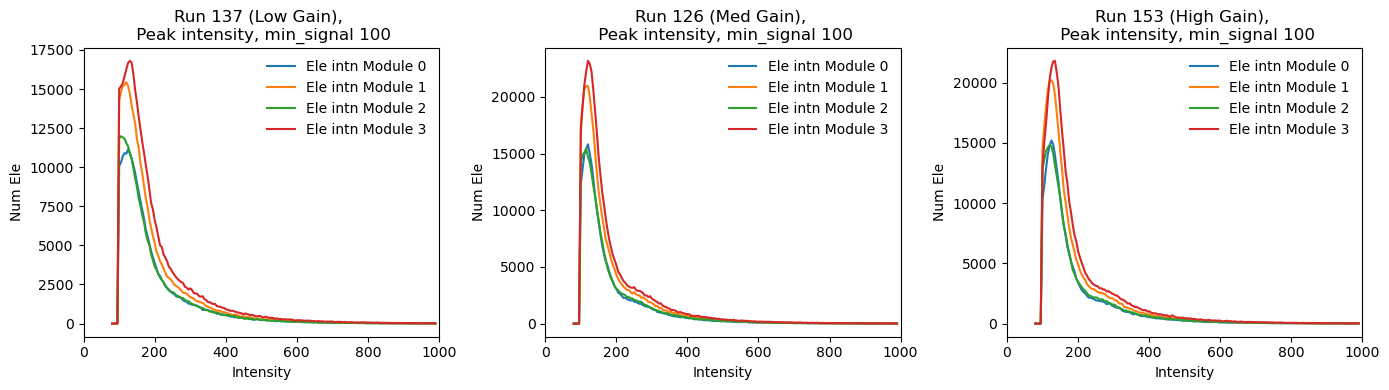

In [17]:
fig,ax=plt.subplots(1,3,figsize=(14,4))
bins_intn=np.arange(80,1000,5)
for plot_num in range(3):
    for i_mdl in range(4):
        hist_intn, bin_edges = np.histogram(intensity_evts[plot_num][:,i_mdl,:].flatten(), bins = bins_intn)
        ax[plot_num].plot(bin_edges[0:-1],hist_intn,label=r"Ele intn Module %i"%(i_mdl))
    ax[plot_num].legend(framealpha=0)
    ax[plot_num].set_xlabel('Intensity')
    ax[plot_num].set_ylabel('Num Ele')
    ax[plot_num].set_title('Run '+str(run_nums[plot_num])+f' ({gain_modes[plot_num]} Gain), \n Peak intensity, min_signal '+str(min_signal));
    ax[plot_num].set_xlim([0,1000])
plt.tight_layout()
plt.show()

In [ ]:
all_counts = []
for i_mdl in range(4):
    hist_intn, bin_edges = np.histogram(Intensity_evts[:,i_mdl,:].flatten(), bins=bins_intn)
    all_counts.append(hist_intn)

avg_counts = np.mean(np.array(all_counts), axis=0)

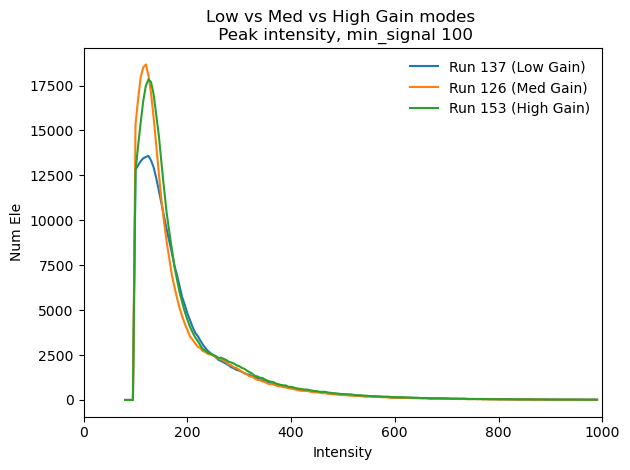

In [35]:
bins_intn=np.arange(80,1000,5)
for plot_num in range(3):
    all_counts = []
    for i_mdl in range(4):
        hist_intn, bin_edges = np.histogram(intensity_evts[plot_num][:,i_mdl,:].flatten(), bins = bins_intn)
        all_counts.append(hist_intn)
    avg_counts = np.mean(np.array(all_counts),axis=0)
    plt.plot(bin_edges[0:-1], avg_counts, label=f'Run {run_nums[plot_num]} ({gain_modes[plot_num]} Gain)')
    plt.legend(framealpha=0)
    plt.xlabel('Intensity')
    plt.ylabel('Num Ele')
    plt.title('Low vs Med vs High Gain modes \n Peak intensity, min_signal '+str(min_signal));
    plt.xlim([0,1000])
plt.tight_layout()
plt.show()